# random — the honest lower-bound baseline

**Algorithm.** Uniformly (or stratified-by-cluster) assign each cell to one
of `n_metacells` buckets.  No use of any feature or graph information.

**Capabilities.** *None.*  This is intentional — `random` is the floor that
every other metacell method must beat to justify its complexity.

**Why is this in the zoo?** Recent benchmarks have argued that random
subsampling may be close to "principled" metacells for many downstream
tasks.  Running `random` on **your own data** is the single best way to
falsify or confirm this for *your* pipeline.

In this notebook we use **Leiden-stratified random** as the primary baseline:
random within each Leiden community, evaluated against the celltype label.
That's the most informative "is metacell worth it?" comparison.

## 1. Setup

In [1]:
# Standard imports + omicverse defaults.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv      # only used for the demo dataset

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess (+ Leiden)

In [2]:
# Pancreas scRNA-seq + Leiden clustering. Leiden is used as the stratification
# key below — it's the *honest* baseline (knows only the coarse graph community,
# not the celltype label we evaluate against).
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
ov.pp.leiden(adata, resolution=0.8)
print('adata:', adata.shape,
      '\n celltypes (eval) :', sorted(adata.obs['clusters'].unique()),
      '\n leiden clusters  :', adata.obs['leiden'].nunique())

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)



╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 17.9065s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ n_genes (int)                                        │
│           │ ✚ n_genes_by_counts (int)                              │
│    

    After filtration, 15737/15737 genes are kept.
    Among 15737 genes, 15736 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.6303s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.94s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.9469s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.6867s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 17:22:49] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.8635s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU

## 3. Fit random partition (stratified by Leiden)

We stratify the random assignment **by Leiden cluster** — random within each
graph community, NOT random against the celltype label (that would be a
tautology).  Section 12 compares the three flavours.

In [3]:
mc = ov.single.MetaCell(
    adata.copy(), method='random', n_metacells=100,
    stratify_key='leiden', random_state=0,
).fit()
print(f'fit done: {mc.method}, runtime={mc._fit_result.runtime_s:.4f} s')

fit done: random, runtime=0.0021 s


## 4. AnnData schema after fit

In [4]:
# Inspect what the fit wrote into adata via the unified schema.
print(f'method      : {mc.method}')
print(f'capabilities: {sorted(mc.capabilities)}')
print(f'n_metacells : {np.unique(mc._fit_result.assignments).size}')
print(f'runtime     : {mc._fit_result.runtime_s:.3f} s')
print(f'uns         : {dict(mc.adata.uns["metacell"])}')

method      : random
capabilities: []
n_metacells : 100
runtime     : 0.002 s
uns         : {'method': 'random', 'n_metacells': 100, 'n_iter': 1, 'converged': True, 'runtime_s': 0.0020720958709716797, 'random_state': 0, 'capabilities': []}


## 5. Aggregate to a metacell AnnData

In [5]:
ad_mc = mc.predicted(method='hard', layer='counts', summary='sum',
                     celltype_label='clusters')
print(f'metacell AnnData: {ad_mc.shape}')
print(f'mean cells/metacell: {ad_mc.obs["n_cells"].mean():.1f}')
ad_mc.obs.head()

metacell AnnData: (100, 2000)
mean cells/metacell: 36.3


,n_cells,clusters,clusters_purity
mc-0,38,Ductal,0.605263
mc-1,39,Ductal,0.717949
mc-2,27,Ductal,0.740741
mc-3,28,Ductal,0.714286
mc-4,31,Ductal,0.580645


## 6. Benchmarking metrics (purity / separation / compactness)

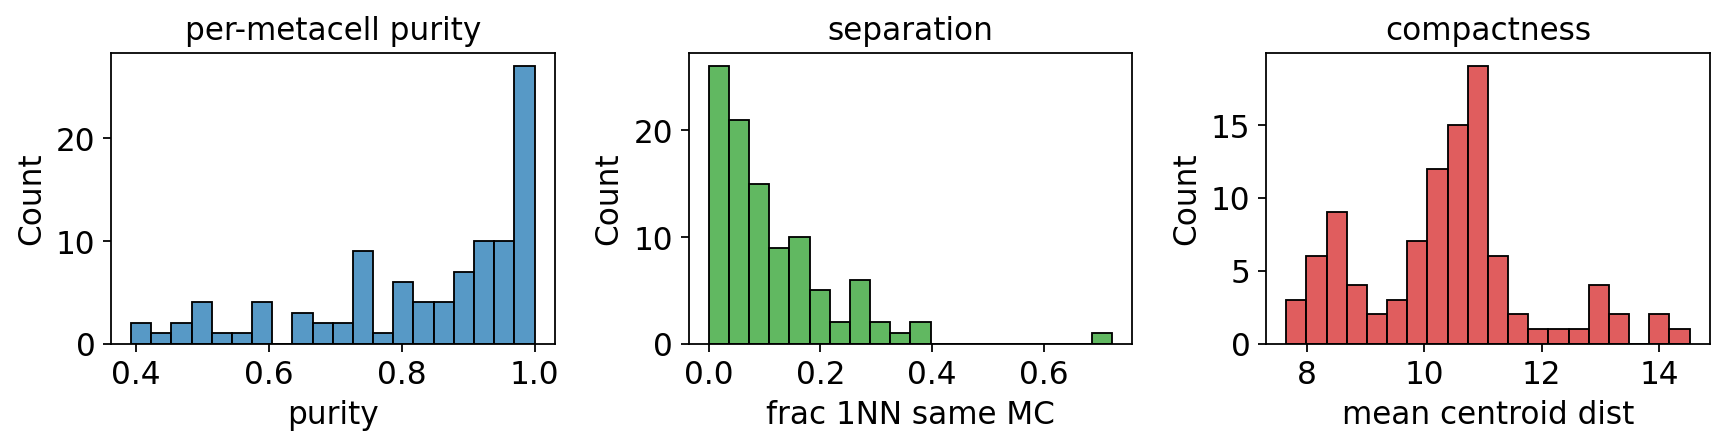

In [6]:
# Compute purity / separation / compactness AND show the 3-panel histogram
# in one call (ov.pl.metacell_metrics returns the per-metacell tables too).
purity, separation, compactness = ov.pl.metacell_metrics(
    mc, label_key='clusters', use_rep='X_pca',
)

## 7. mcRigor: statistical validation

In [7]:
# mcRigor's double-permutation null. dubious_rate = fraction of cells in
# heterogeneous metacells; rigor_score = 1 - 0.5*(dubious_rate + zero_rate).
rep = mc.check_rigor(layer_lognorm='lognorm', n_rep=20,
                     feature_use=1000, random_state=0)
print(f'rigor_score : {rep.score:.3f}')
print(f'dubious_rate: {rep.dubious_rate:.3f}')
print(f'zero_rate   : {rep.zero_rate:.3f}')
print(f'# metacells : {rep.n_metacells}')

rigor_score : 0.523
dubious_rate: 0.720
zero_rate   : 0.233
# metacells : 100


### 7.1 Per-metacell `mcDiv` vs size

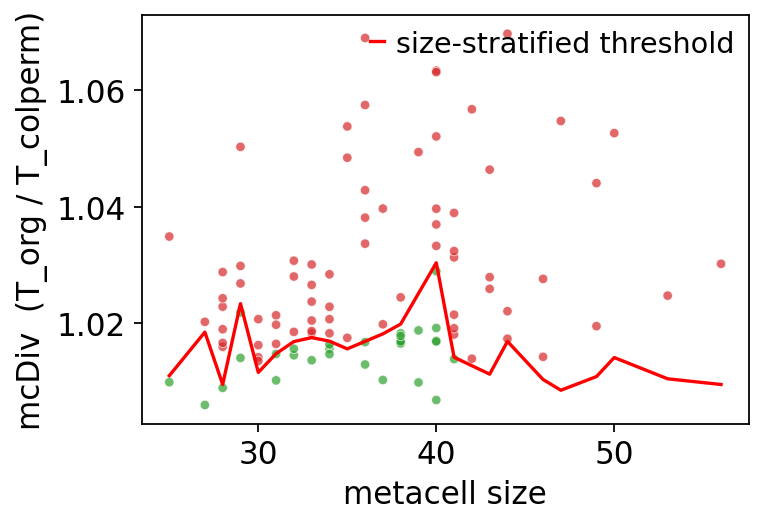

<Axes: xlabel='metacell size', ylabel='mcDiv  (T_org / T_colperm)'>

In [8]:
# mcDiv vs metacell size, overlaid with size-stratified threshold.
ov.pl.rigor_scatter(rep)

## 8. UMAP with metacell centroids

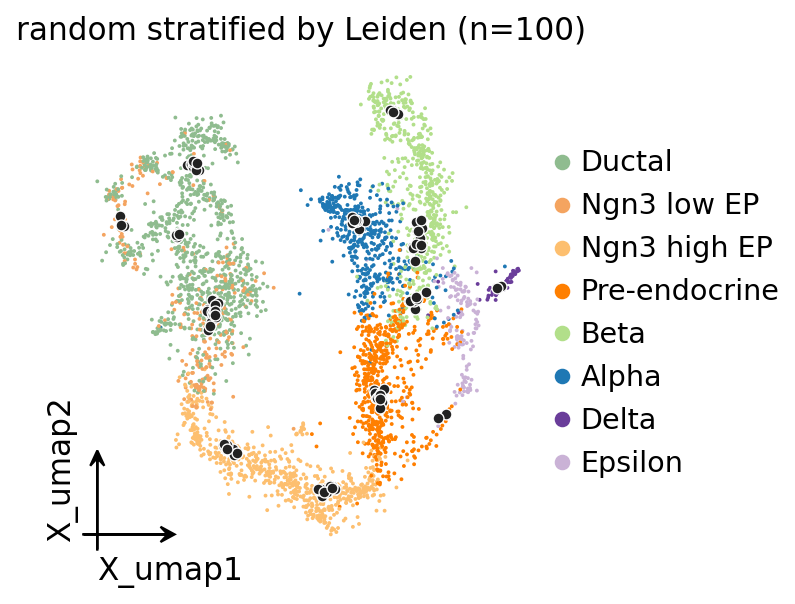

In [9]:
# UMAP coloured by celltype with metacell centroids overlaid in dark grey.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ov.pl.embedding(mc.adata, basis='X_umap', color='clusters', ax=ax, show=False,
                frameon='small', title='random stratified by Leiden (n=100)', size=12)
labels = mc._fit_result.assignments
pts = np.array([mc.adata.obsm['X_umap'][labels == u].mean(axis=0)
                for u in np.unique(labels)])
ax.scatter(pts[:, 0], pts[:, 1], s=24, c='#222',
           edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 9. Per-celltype purity boxplot

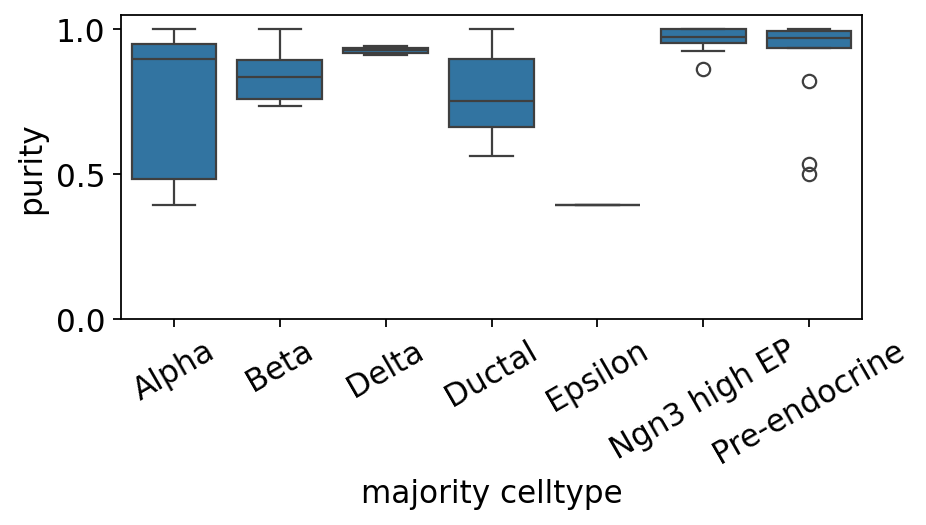

<Axes: xlabel='majority celltype', ylabel='purity'>

In [10]:
# Per-celltype boxplot of metacell purity.
ov.pl.metacell_purity_box(mc, label_key='clusters')

## 10. Metacell-level UMAP

🔍 [2026-05-19 17:23:10] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': F

   🔧 PCA solver used: covariance_eigh
    finished✅ (1.25s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.2555s                                                 │
│  Shape:    100 x 2,000 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 100x30)                                │
│           │ ✚ scaled|original|X_pca (array, 100x30)                │
│         

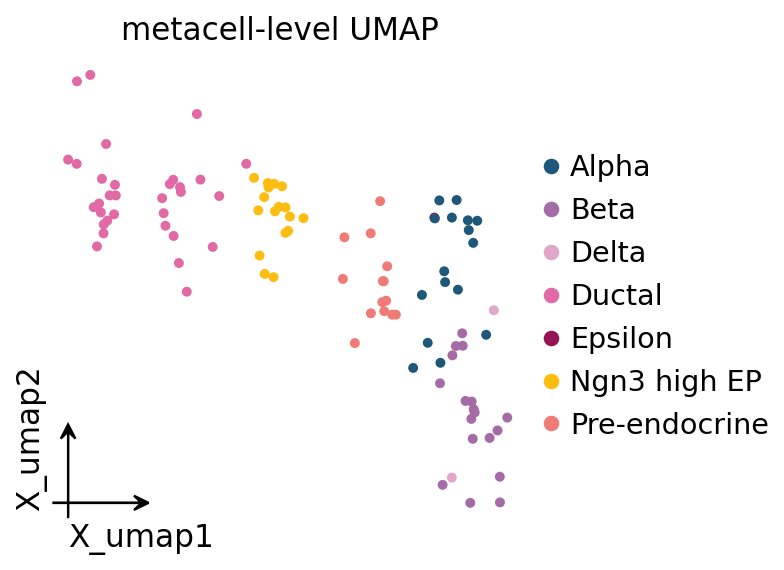

In [11]:
# Treat the metacell AnnData as a smaller dataset and run the standard
# omicverse preprocess -> pca -> neighbors -> umap loop on it.
ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                          n_HVGs=min(2000, ad_mc.n_vars))
ad_mc = ad_mc[:, ad_mc.var.highly_variable_features]
ov.pp.scale(ad_mc)
ov.pp.pca(ad_mc, layer='scaled', n_pcs=min(30, ad_mc.n_obs - 1))
ad_mc.obsm['X_pca'] = ad_mc.obsm['scaled|original|X_pca']
ov.pp.neighbors(ad_mc, n_neighbors=min(15, ad_mc.n_obs - 1), use_rep='X_pca')
ov.pp.umap(ad_mc)
ov.pl.embedding(ad_mc, basis='X_umap', color='clusters',
                frameon='small', title='metacell-level UMAP', size=80)

## 11. Top markers per celltype on the metacell AnnData

In [12]:
# Find top markers per celltype on the metacell AnnData (omicverse helper —
# drops the categories with <2 metacells automatically and reports cell-type
# fractions ``pts`` along with the gene names).
counts = ad_mc.obs['clusters'].value_counts()
keep = counts[counts >= 2].index.tolist()
ad_mc_for_de = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
ad_mc_for_de.obs['clusters'] = ad_mc_for_de.obs['clusters'].astype('category')

ov.single.find_markers(ad_mc_for_de, groupby='clusters', method='wilcoxon',
                       key_added='rank_genes_groups', pts=True, use_gpu=False)
ov.single.get_markers(ad_mc_for_de, n_genes=3, key='rank_genes_groups')

🔍 Finding marker genes | method: wilcoxon | groupby: clusters | n_groups: 6 | n_genes: 50
✅ Done | 6 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']


,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,Alpha,1,Dusp10,6.311893,3.057781,2.756418e-10,3.354118e-08,1.0,0.939759
1,Alpha,2,Tmem27,6.311893,6.295933,2.756418e-10,3.354118e-08,1.0,0.867470
2,Alpha,3,Irx2,6.311893,7.536649,2.756418e-10,3.354118e-08,1.0,0.385542
3,Beta,1,Sytl4,6.613622,6.880722,3.750279e-11,4.426620e-09,1.0,0.432099
4,Beta,2,Adra2a,6.613622,5.380252,3.750279e-11,4.426620e-09,1.0,0.567901
5,Beta,3,1110008P14Rik,6.613622,2.687311,3.750279e-11,4.426620e-09,1.0,1.000000
6,Delta,1,Klhdc8b,2.412468,2.531159,1.584494e-02,3.488716e-01,1.0,1.000000
7,Delta,2,Tacr3,2.412468,7.677285,1.584494e-02,3.488716e-01,1.0,0.020619
8,Delta,3,Unc5c,2.412468,5.006094,1.584494e-02,3.488716e-01,1.0,0.288660
9,Ductal,1,Cldn3,8.019975,3.210117,1.057666e-15,1.596713e-14,1.0,1.000000


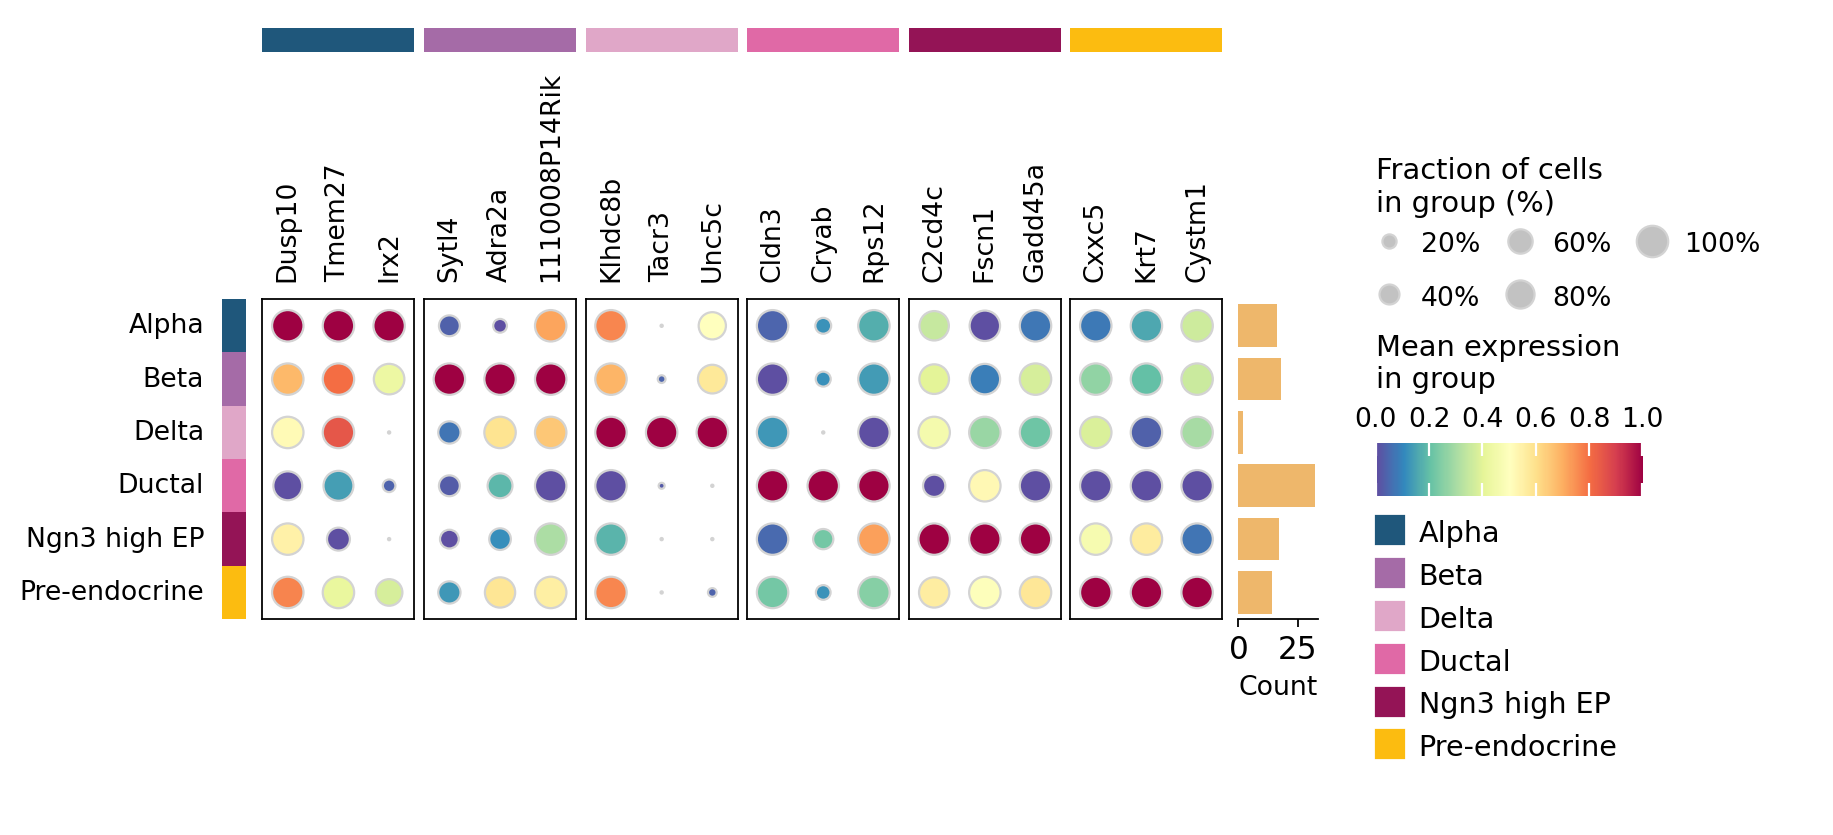

In [13]:
# Dotplot of top markers per metacell-level celltype.
ov.pl.markers_dotplot(ad_mc_for_de, groupby='clusters', n_genes=3,
                      key='rank_genes_groups')

## 12. Three random-baseline modes compared

1. **uniform**: no stratification at all.  Each cell gets a random metacell
   id in `[0, n_metacells)`.  This is the **floor** — purity ≈ largest-cluster
   proportion.
2. **stratify by Leiden** (our primary baseline above): each metacell stays
   inside one Leiden community.  The *honest* baseline a real pipeline can
   match without seeing celltype labels.
3. **stratify by celltype** (tautology): each metacell stays inside one
   celltype.  Mean purity is trivially 1.0; useful only as a sanity check
   that purity computation works.

In [14]:
# Three random flavours.
mc_uniform = ov.single.MetaCell(
    adata.copy(), method='random', n_metacells=100, random_state=0,
).fit()
mc_strat_celltype = ov.single.MetaCell(
    adata.copy(), method='random', n_metacells=100,
    stratify_key='clusters', random_state=0,
).fit()
p_uniform   = mc_uniform.compute_purity('clusters').purity.mean()
p_leiden    = mc.compute_purity('clusters').purity.mean()
p_strat_ct  = mc_strat_celltype.compute_purity('clusters').purity.mean()
print(f'uniform random            : mean purity = {p_uniform:.3f}  (the floor)')
print(f'stratified by Leiden      : mean purity = {p_leiden:.3f}  (honest baseline)')
print(f'stratified by celltype    : mean purity = {p_strat_ct:.3f}  (tautology)')

uniform random            : mean purity = 0.282  (the floor)
stratified by Leiden      : mean purity = 0.832  (honest baseline)
stratified by celltype    : mean purity = 1.000  (tautology)


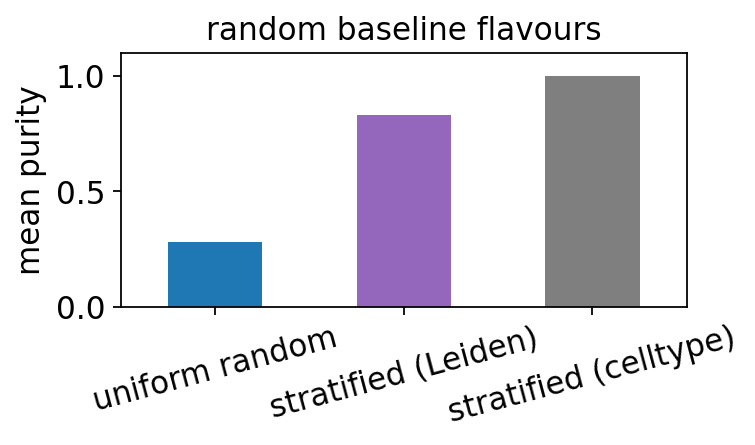

In [15]:
# Bar chart comparing the three flavours.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
pd.Series({
    'uniform random': p_uniform,
    'stratified (Leiden)': p_leiden,
    'stratified (celltype)': p_strat_ct,
}).plot.bar(ax=ax, color=['#1f77b4', '#9467bd', '#7f7f7f'])
ax.set_ylabel('mean purity'); ax.set_ylim(0, 1.1)
ax.set_title('random baseline flavours')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

## 13. Save / load roundtrip

In [16]:
# Save/load roundtrip — every backend supports this.
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
    path = f.name
mc.save(path)

mc2 = ov.single.MetaCell(adata.copy(), method='random', n_metacells=100,
                          use_rep='X_pca', random_state=0)
mc2.load(path)
print(f'saved+loaded {path}')
os.remove(path)

saved+loaded /tmp/tmp4pgzs5vd.pkl


## 14. Takeaways

- The primary "random" baseline here is **stratified by Leiden** — it knows
  only the cell's coarse graph community, which any pipeline can compute
  without seeing celltype labels.  This is the honest floor any principled
  metacell method must beat.
- **Never stratify by the evaluation label**: stratifying by `clusters` gives
  tautological mean purity = 1.0.
- Uniform random produces mean purity ≈ largest-cluster fraction (~0.28
  here); it's only useful as the absolute floor.
- A working pipeline should show: `random (uniform) < random (Leiden) ≤
  kmeans < seacells / metaq` on purity.  If a principled method can't beat
  stratified-Leiden random, it's not learning anything beyond what Leiden
  already gave you.